# 8 # 
Fit some of the non-linear models investigated in this chapter to the
Auto data set. Is there evidence for non-linear relationships in this
data set? Create some informative plots to justify your answer.

In [123]:
import numpy as np
import pandas as pd
from pygam import (LinearGAM,
                   s as s_gam,
                   l as l_gam,
                   f as f_gam)
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm
from ISLP.models import (poly, bs, ns, ModelSpec)
from ISLP.transforms import (BSpline,
                            NaturalSpline)
from ISLP import load_data
from ISLP.pygam import (anova as anova_gam,
                        approx_lam,
                        plot as plot_gam)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib.pyplot import subplots

In [124]:
Auto = load_data('Auto')
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [125]:
Auto.corr()['mpg']

mpg             1.000000
cylinders      -0.777618
displacement   -0.805127
horsepower     -0.778427
weight         -0.832244
acceleration    0.423329
year            0.580541
origin          0.565209
Name: mpg, dtype: float64

In [126]:
Auto.origin.value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

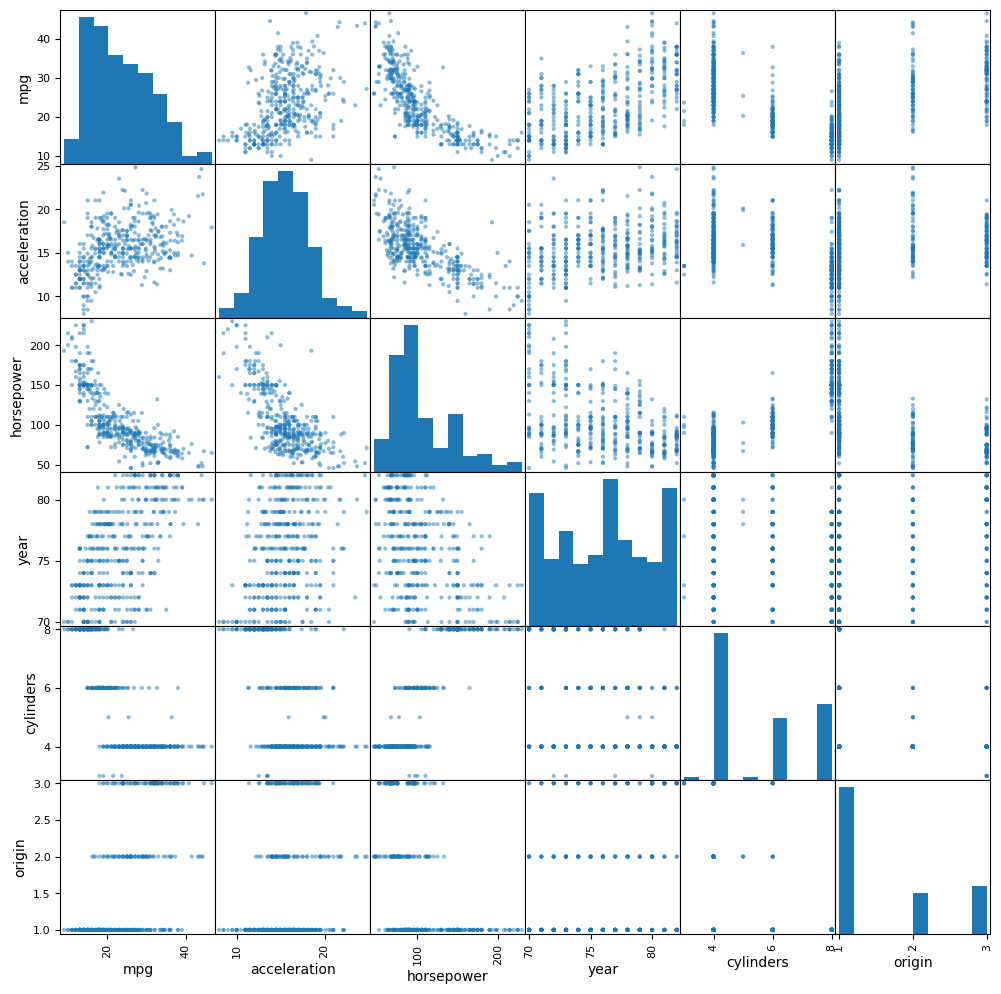

In [127]:
colunas = ['mpg', 'acceleration', 'horsepower', 'year', 'cylinders','origin']
pd.plotting.scatter_matrix(Auto[colunas], figsize=(12,12));

In [128]:
y = Auto['mpg']
X = Auto[['acceleration', 'horsepower', 'year', 'cylinders', 'origin']]
mpg_df = np.linspace(y.min(), y.max(), 100)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state=42)

# Polynomial #

In [129]:
ms_accel_poly = [ModelSpec([poly('acceleration',degree=grau)]) for grau in range(1,11)]
X_accel_poly = [modelo.fit_transform(X_treino) for modelo in ms_accel_poly]
modelos_accel_poly = [OLS(y_treino, X_).fit() for X_ in X_accel_poly]
anova_lm(*modelos_accel_poly)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,292.0,15468.860723,0.0,NaN,NaN,NaN
1,291.0,15044.516679,1.0,424.344044,8.138991,0.004643
2,290.0,15044.370695,1.0,0.145984,0.002800,0.957836
3,289.0,14889.781037,1.0,154.589658,2.965056,0.086151
4,288.0,14862.888513,1.0,26.892524,0.515803,0.473220
5,287.0,14826.689396,1.0,36.199117,0.694305,0.405397
6,286.0,14826.596402,1.0,0.092994,0.001784,0.966342
7,285.0,14799.588321,1.0,27.008080,0.518020,0.472277
8,284.0,14760.847857,1.0,38.740465,0.743049,0.389413
9,283.0,14754.822143,1.0,6.025714,0.115574,0.734137


In [130]:
predicao_treino_accel = [modelo.predict(X_) for modelo, X_ in zip(modelos_accel_poly, X_accel_poly)]
mse_treino_accel = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_accel]
predicao_teste_accel = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_accel_poly, ms_accel_poly)]
mse_teste_accel = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_accel]

pd.DataFrame({'MSE_treino':mse_treino_accel, 'MSE_teste':mse_teste_accel})

,MSE_treino,MSE_teste
0,52.615173,41.985900
1,51.171825,43.104726
2,51.171329,43.164635
3,50.645514,40.647306
4,50.554043,40.737840
5,50.430916,40.605083
6,50.430600,40.587401
7,50.338736,40.664027
8,50.206965,40.152136
9,50.186470,40.550664


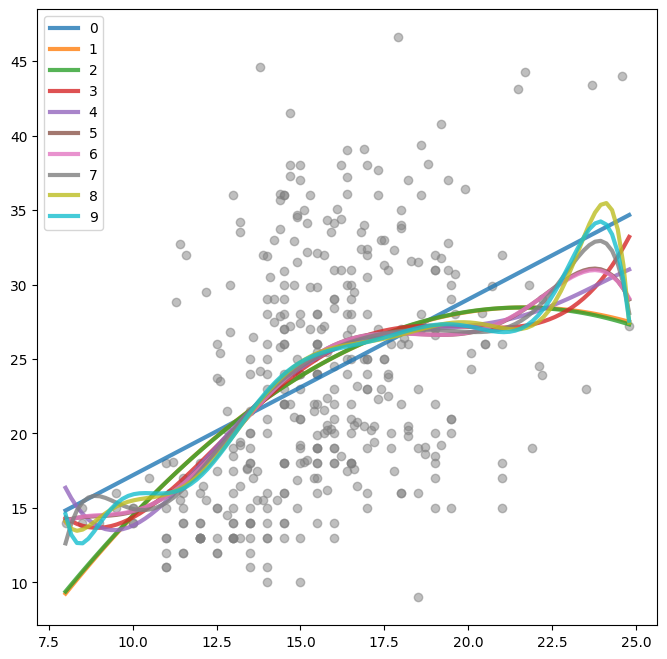

In [131]:
ax = subplots(figsize=(8,8))[1]
df_accel = pd.DataFrame({'acceleration':np.linspace(Auto['acceleration'].min(), Auto['acceleration'].max(),100)})
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for modelo, ms, i in zip(modelos_accel_poly, ms_accel_poly, range(0, 11)):
    ax.plot(df_accel.values, modelo.predict(ms.transform(df_accel)), alpha=0.8, linewidth=3, label=f'{i}')
ax.legend();

In [132]:
for coluna in ['acceleration', 'horsepower', 'year', 'cylinders']:
    print(f'**********************{coluna}**********************')
    ms_poly = [ModelSpec([poly(coluna,degree=grau)]) for grau in range(1,11)]
    X_poly = [modelo.fit_transform(X_treino) for modelo in ms_poly]
    modelos_poly = [OLS(y_treino, X_).fit() for X_ in X_poly]
    print(anova_lm(*modelos_poly))
    predicao_treino = [modelo.predict(X_) for modelo, X_ in zip(modelos_poly, X_poly)]
    mse_treino = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino]
    predicao_teste = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_poly, ms_poly)]
    mse_teste = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste]
    print(pd.DataFrame({'MSE_treino':mse_treino, 'MSE_teste':mse_teste}))
    print(f'******************************************************\n')

**********************acceleration**********************
   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     292.0  15468.860723      0.0         NaN       NaN       NaN
1     291.0  15044.516679      1.0  424.344044  8.138991  0.004643
2     290.0  15044.370695      1.0    0.145984  0.002800  0.957836
3     289.0  14889.781037      1.0  154.589658  2.965056  0.086151
4     288.0  14862.888513      1.0   26.892524  0.515803  0.473220
5     287.0  14826.689396      1.0   36.199117  0.694305  0.405397
6     286.0  14826.596402      1.0    0.092994  0.001784  0.966342
7     285.0  14799.588321      1.0   27.008080  0.518020  0.472277
8     284.0  14760.847857      1.0   38.740465  0.743049  0.389413
9     283.0  14754.822143      1.0    6.025714  0.115574  0.734137
   MSE_treino  MSE_teste
0   52.615173  41.985900
1   51.171825  43.104726
2   51.171329  43.164635
3   50.645514  40.647306
4   50.554043  40.737840
5   50.430916  40.605083
6   50.430600  40.587401
7   50

# Step Functions #

In [133]:
X_treino_qcut = []
X_teste_qcut = []
faixas_qcut = []
modelos_qcut = []
for i in range(1,11):
    coluna = 'acceleration'
    X_, faixa_corte = pd.qcut(X_treino[coluna], i, retbins=True)
    faixas_qcut.append(faixa_corte)
    X_treino_qcut.append(pd.get_dummies(X_))
    X_teste_qcut.append(pd.get_dummies(pd.cut(X_teste[coluna], bins=faixa_corte)))
    modelos_qcut = [OLS(y_treino, X_).fit() for X_ in X_treino_qcut]

df_anova_qcut = anova_lm(*modelos_qcut)
df_anova_qcut

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,293.0,18805.232007,0.0,NaN,NaN,NaN
1,292.0,16888.384801,1.0,1916.847206,37.688593,2.702522e-09
2,291.0,15287.167092,1.0,1601.217709,31.482761,4.686044e-08
3,290.0,14951.644182,1.0,335.522910,6.596972,1.071586e-02
4,289.0,15148.225976,1.0,-196.581794,-3.865144,1.000000e+00
5,288.0,14925.211303,1.0,223.014673,4.384861,3.713353e-02
6,287.0,14785.838826,1.0,139.372477,2.740308,9.893889e-02
7,286.0,14604.318555,1.0,181.520271,3.569008,5.987896e-02
8,285.0,14490.173717,1.0,114.144838,2.244289,1.352153e-01
9,284.0,14444.280399,1.0,45.893318,0.902343,3.429618e-01


In [134]:
pd.DataFrame(faixas_qcut)

,0,1,2,3,4,5,6,7,8,9,10
0,8.0,24.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.0,15.400000,24.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8.0,14.266667,16.500000,24.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8.0,13.500000,15.400000,17.300000,24.800000,NaN,NaN,NaN,NaN,NaN,NaN
4,8.0,13.200000,14.500000,16.000000,17.840000,24.800000,NaN,NaN,NaN,NaN,NaN
5,8.0,12.983333,14.266667,15.400000,16.500000,18.200000,24.8,NaN,NaN,NaN,NaN
6,8.0,12.500000,13.971429,14.857143,15.842857,17.000000,18.6,24.800,NaN,NaN,NaN
7,8.0,12.500000,13.500000,14.500000,15.400000,16.400000,17.3,18.875,24.80,NaN,NaN
8,8.0,12.055556,13.411111,14.266667,14.922222,15.777778,16.5,17.600,19.00,24.8,NaN
9,8.0,12.000000,13.200000,14.000000,14.500000,15.400000,16.0,16.900,17.84,19.0,24.8


In [135]:
pd.DataFrame([{'MSE_treino':mean_squared_error(y_treino,modelo.predict(X_)),
  'MSE_teste': mean_squared_error(y_teste, modelo.predict(X__))} for modelo, X_, X__ in zip(modelos_qcut, X_treino_qcut, X_teste_qcut)])

,MSE_treino,MSE_teste
0,63.963374,51.403404
1,57.443486,49.255251
2,51.997167,42.911388
3,50.855933,41.373315
4,51.524578,42.090617
5,50.766025,43.463267
6,50.291969,42.123546
7,49.674553,41.635138
8,49.286305,43.053346
9,49.130205,38.118906


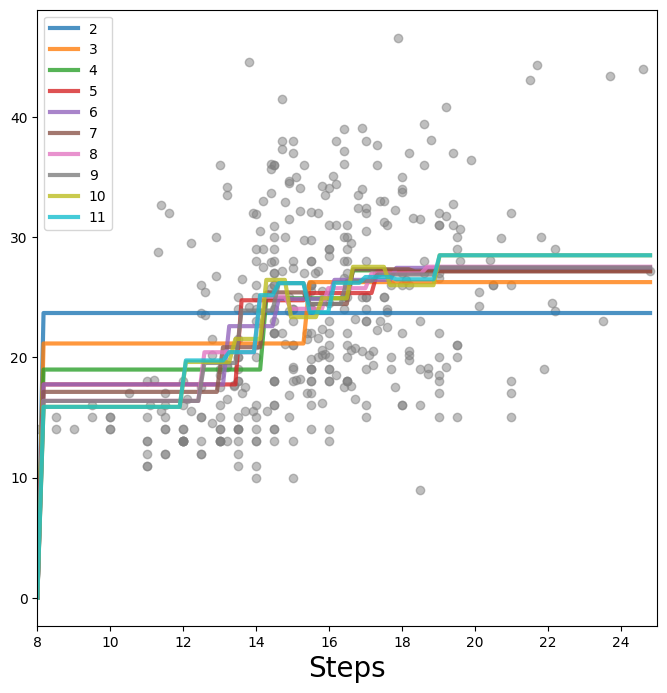

In [136]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for m, faixa in zip(modelos_qcut, faixas_qcut):
    ax.plot(df_accel.values, m.predict(pd.get_dummies(pd.cut(df_accel['acceleration'],bins=faixa))), alpha=0.8, linewidth=3, label=f'{len(faixa)}')
ax.set_xlabel('Steps', fontsize=20)
ax.set_xlim(8,25)
ax.legend();

In [137]:
def modelos_step_function(X_treino, y_treino, X_teste, y_teste, coluna, faixa_inicio=2, faixa_fim=11):
    X_treino_qcut = []
    X_teste_qcut = []
    faixas_qcut = []
    modelos_qcut = []
    for i in range(faixa_inicio, faixa_fim):
        X_, faixa_corte = pd.qcut(X_treino[coluna], i, retbins=True)
        faixas_qcut.append(faixa_corte)
        X_treino_qcut.append(pd.get_dummies(X_))
        X_teste_qcut.append(pd.get_dummies(pd.cut(X_teste[coluna], bins=faixa_corte)))
        modelos_qcut = [OLS(y_treino, X_).fit() for X_ in X_treino_qcut]

    df_anova_qcut = anova_lm(*modelos_qcut)
    df_faixas_qcut = pd.DataFrame(faixas_qcut)
    df_mse_qcut = pd.DataFrame([{'MSE_treino':mean_squared_error(y_treino,modelo.predict(X_)),
                'MSE_teste': mean_squared_error(y_teste, modelo.predict(X__))} for modelo, X_, X__ in zip(modelos_qcut, 
                                                                                                            X_treino_qcut, 
                                                                                                            X_teste_qcut)])
    return modelos_qcut, df_anova_qcut, df_faixas_qcut, df_mse_qcut


for coluna in ['acceleration', 'horsepower', 'year']:
    m, df_a, df_f, df_mse = modelos_step_function(X_treino, y_treino, X_teste, y_teste, coluna)
    print(f'************************{coluna}************************')
    print(df_a)
    print(df_mse)
    print(f'********************************************************\n')

************************acceleration************************
   df_resid           ssr  df_diff      ss_diff          F        Pr(>F)
0     292.0  16888.384801      0.0          NaN        NaN           NaN
1     291.0  15287.167092      1.0  1601.217709  31.482761  4.686044e-08
2     290.0  14951.644182      1.0   335.522910   6.596972  1.071586e-02
3     289.0  15148.225976      1.0  -196.581794  -3.865144  1.000000e+00
4     288.0  14925.211303      1.0   223.014673   4.384861  3.713353e-02
5     287.0  14785.838826      1.0   139.372477   2.740308  9.893889e-02
6     286.0  14604.318555      1.0   181.520271   3.569008  5.987896e-02
7     285.0  14490.173717      1.0   114.144838   2.244289  1.352153e-01
8     284.0  14444.280399      1.0    45.893318   0.902343  3.429618e-01
   MSE_treino  MSE_teste
0   57.443486  49.255251
1   51.997167  42.911388
2   50.855933  41.373315
3   51.524578  42.090617
4   50.766025  43.463267
5   50.291969  42.123546
6   49.674553  41.635138
7   49.28

# Splines #

In [148]:
modeleladores_spline = [ModelSpec([bs('acceleration', df=graus_liberdade, degree=0)]) for graus_liberdade in range(1,9)]
X_treino_spline = [modelador.fit_transform(X_treino) for modelador in modeleladores_spline]
modelos_spline = [OLS(y_treino, X_).fit() for X_ in X_treino_spline]
anova_lm(*modelos_spline)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,292.0,16973.064989,0.0,NaN,NaN,NaN
1,291.0,15368.633108,1.0,1604.431881,31.204536,5.333120e-08
2,290.0,15307.207989,1.0,61.425119,1.194655,2.752997e-01
3,289.0,15107.977701,1.0,199.230287,3.874822,4.997105e-02
4,288.0,14984.858129,1.0,123.119572,2.394548,1.228571e-01
5,287.0,14815.552795,1.0,169.305334,3.292813,7.062763e-02
6,286.0,14973.355025,1.0,-157.802231,-3.069090,1.000000e+00
7,285.0,14653.737849,1.0,319.617176,6.216223,1.322589e-02


In [149]:
predicao_treino_splines = [modelo.predict(X_) for modelo, X_ in zip(modelos_spline, X_treino_spline)]
mse_treino_spline = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_splines]
predicao_teste_splines = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_spline, modeleladores_spline)]
mse_teste_spline = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_splines]

pd.DataFrame({'MSE_treino':mse_treino_spline, 'MSE_teste':mse_teste_spline})

,MSE_treino,MSE_teste
0,57.731514,49.152882
1,52.274262,42.556796
2,52.065333,44.451713
3,51.387679,41.890578
4,50.968905,43.043463
5,50.393037,41.867786
6,50.929779,41.669275
7,49.842646,42.699538


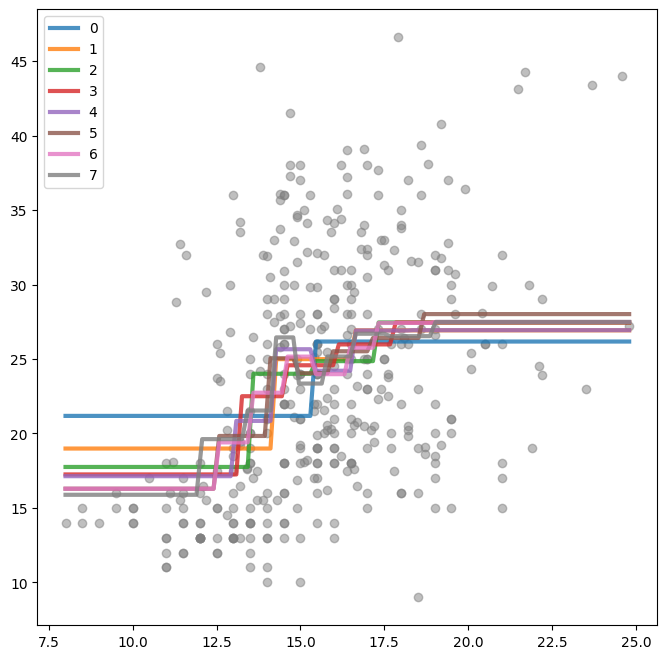

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for modelo, ms, i in zip(modelos_spline, modeleladores_spline, range(0, 11)):
    ax.plot(df_accel.values, modelo.predict(ms.transform(df_accel)), alpha=0.8, linewidth=3, label=f'{i}')
ax.legend();

# Natural Splines #

In [180]:
modeleladores_naturalspline = [ModelSpec([ns('acceleration', df=graus_liberdade)]) for graus_liberdade in range(1,9)]
X_treino_naturalspline = [modelador.fit_transform(X_treino) for modelador in modeleladores_naturalspline]
modelos_naturalspline = [OLS(y_treino, X_).fit() for X_ in X_treino_naturalspline]
anova_lm(*modelos_naturalspline)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,292.0,15468.860723,0.0,NaN,NaN,NaN
1,291.0,14997.513971,1.0,471.346752,9.257742,0.002559
2,290.0,15000.072444,1.0,-2.558473,-0.050251,1.000000
3,289.0,14865.663725,1.0,134.408719,2.639927,0.105298
4,288.0,14755.576546,1.0,110.087179,2.162227,0.142531
5,287.0,14727.076550,1.0,28.499996,0.559770,0.454966
6,286.0,14564.601964,1.0,162.474586,3.191170,0.075096
7,285.0,14510.431534,1.0,54.170430,1.063964,0.303187


In [187]:
predicao_treino_naturalsplines = [modelo.predict(X_) for modelo, X_ in zip(modelos_naturalspline, X_treino_naturalspline)]
mse_treino_naturalspline = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_naturalsplines]
predicao_teste_naturalspline = [modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_naturalspline, modeleladores_naturalspline)]
mse_teste_naturalspline = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_naturalspline]

pd.DataFrame({'MSE_treino':mse_treino_naturalspline, 'MSE_teste':mse_teste_naturalspline})

,MSE_treino,MSE_teste
0,52.615173,41.985900
1,51.011952,42.658071
2,51.020655,42.778851
3,50.563482,40.427875
4,50.189036,40.683080
5,50.092097,40.615166
6,49.539462,40.090292
7,49.355209,39.800824


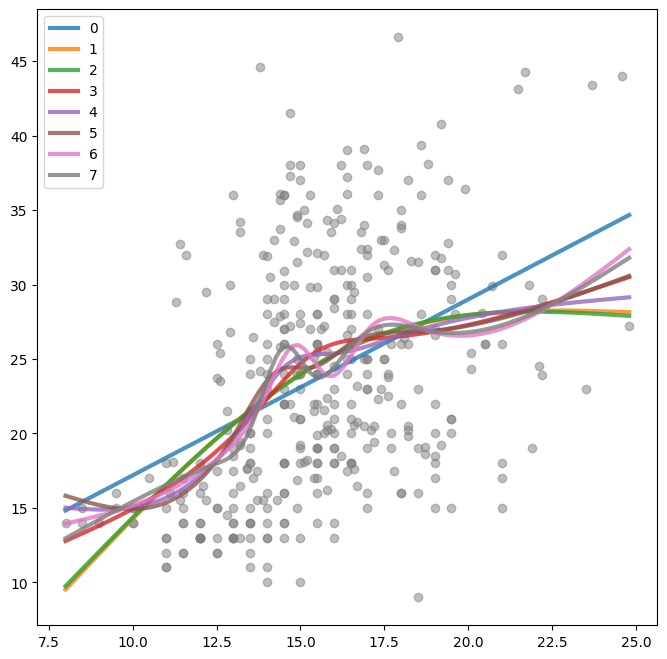

In [179]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for modelo, ms, i in zip(modelos_naturalspline, modeleladores_naturalspline, range(0, 11)):
    ax.plot(df_accel.values, modelo.predict(ms.transform(df_accel)), alpha=0.8, linewidth=3, label=f'{i}')
ax.legend();